<a href="https://colab.research.google.com/github/adityaaaa342/Pattern-Recognition-/blob/main/pactical_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q scikit-learn scipy seaborn pandas numpy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style("whitegrid")
np.random.seed(42)

In [3]:
def generate_synthetic_data(n=500):
    segs = []
    segs.append(pd.DataFrame({
        "Age": np.random.normal(35, 8, n//4).clip(18,70),
        "AnnualIncome": np.random.normal(25000,5000,n//4).clip(8000,None),
        "SpendingScore": np.random.normal(25,10,n//4).clip(1,100),
        "PurchaseFrequency": np.random.normal(12,3,n//4).clip(1,None)}))
    segs.append(pd.DataFrame({
        "Age": np.random.normal(40,10,n//4).clip(18,70),
        "AnnualIncome": np.random.normal(90000,15000,n//4).clip(8000,None),
        "SpendingScore": np.random.normal(80,10,n//4).clip(1,100),
        "PurchaseFrequency": np.random.normal(20,4,n//4).clip(1,None)}))
    segs.append(pd.DataFrame({
        "Age": np.random.normal(50,9,n//4).clip(18,70),
        "AnnualIncome": np.random.normal(85000,12000,n//4).clip(8000,None),
        "SpendingScore": np.random.normal(20,8,n//4).clip(1,100),
        "PurchaseFrequency": np.random.normal(5,2,n//4).clip(1,None)}))
    segs.append(pd.DataFrame({
        "Age": np.random.normal(24,4,n//4).clip(18,70),
        "AnnualIncome": np.random.normal(35000,7000,n//4).clip(8000,None),
        "SpendingScore": np.random.normal(75,12,n//4).clip(1,100),
        "PurchaseFrequency": np.random.normal(15,3,n//4).clip(1,None)}))
    df = pd.concat(segs, ignore_index=True)
    df.insert(0, "CustomerID", range(1, len(df)+1))
    return df.sample(frac=1, random_state=42).reset_index(drop=True)

df = generate_synthetic_data(500)
print("Dataset shape:", df.shape)
display(df.head())
print(df.describe())


Dataset shape: (500, 5)


,CustomerID,Age,AnnualIncome,SpendingScore,PurchaseFrequency
0,362,51.956896,105132.409769,24.634332,2.163269
1,74,47.517149,25291.043592,45.923873,10.458399
2,375,64.700884,66329.252246,31.769363,6.185054
3,156,46.385925,90888.276510,81.777010,20.185746
4,105,33.709714,28397.988745,24.809838,15.358725


       CustomerID         Age   AnnualIncome  SpendingScore  PurchaseFrequency
count  500.000000  500.000000     500.000000     500.000000         500.000000
mean   250.500000   37.550396   58735.365282      50.142445          13.300066
std    144.481833   12.723514   30129.655455      29.252535           6.281856
min      1.000000   18.000000   14874.287067       1.000000           1.067287
25%    125.750000   26.511589   29317.080471      22.779151           8.030142
50%    250.500000   35.884306   49891.076615      46.431079          13.593898
75%    375.250000   46.922919   86253.936454      76.944672          17.748842
max    500.000000   70.000000  128600.397049     100.000000          30.107730


In [4]:

features = ["Age", "AnnualIncome", "SpendingScore", "PurchaseFrequency"]
X = df[features].fillna(df[features].median())
X_scaled = StandardScaler().fit_transform(X)

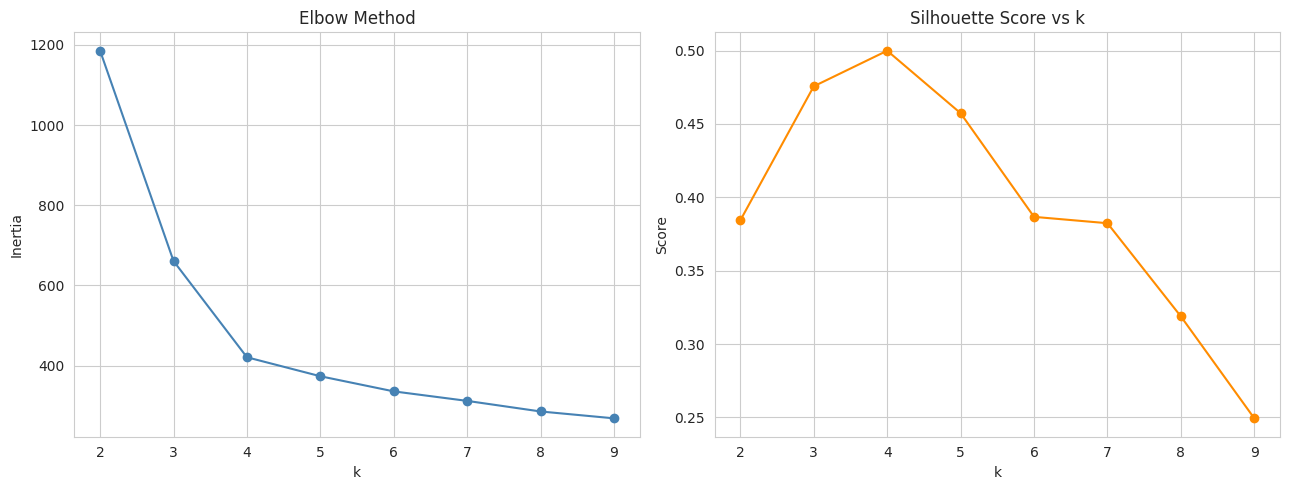

Best k by silhouette score: 4


In [5]:
inertias, sil_scores = [], []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13,5))
axes[0].plot(K_range, inertias, marker="o", color="steelblue")
axes[0].set_title("Elbow Method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(K_range, sil_scores, marker="o", color="darkorange")
axes[1].set_title("Silhouette Score vs k"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Score")
plt.tight_layout(); plt.show()

best_k = K_range[int(np.argmax(sil_scores))]
print(f"Best k by silhouette score: {best_k}")

In [6]:
kmeans = KMeans(n_clusters=best_k, init="k-means++", n_init=10, random_state=42)
df["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)
print(f"K-Means Silhouette: {silhouette_score(X_scaled, df['KMeans_Cluster']):.3f}")
print(f"K-Means Davies-Bouldin: {davies_bouldin_score(X_scaled, df['KMeans_Cluster']):.3f}")


K-Means Silhouette: 0.500
K-Means Davies-Bouldin: 0.715


In [7]:
print("\n=== K-Means Cluster Profiles ===")
print(df.groupby("KMeans_Cluster")[features].mean().round(1))

def label_segment(row):
    if row["AnnualIncome"] > X["AnnualIncome"].median() and row["SpendingScore"] > X["SpendingScore"].median():
        return "High-Value Loyalist"
    elif row["AnnualIncome"] > X["AnnualIncome"].median():
        return "Careful High-Earner"
    elif row["SpendingScore"] > X["SpendingScore"].median():
        return "Young Impulsive Spender"
    else:
        return "Budget Shopper"

profile = df.groupby("KMeans_Cluster")[features].mean()
df["Segment_Label"] = df["KMeans_Cluster"].map(profile.apply(label_segment, axis=1))
print("\n=== Segment Sizes ===")
print(df["Segment_Label"].value_counts())


=== K-Means Cluster Profiles ===
                 Age  AnnualIncome  SpendingScore  PurchaseFrequency
KMeans_Cluster                                                      
0               34.4       25717.0           25.8               11.8
1               40.3       88354.0           80.9               20.6
2               52.1       85278.1           19.6                5.5
3               23.9       36892.3           74.4               15.3

=== Segment Sizes ===
Segment_Label
Young Impulsive Spender    127
Budget Shopper             126
Careful High-Earner        124
High-Value Loyalist        123
Name: count, dtype: int64


In [8]:
df.to_csv("customer_segments_output.csv", index=False)
print("\nSaved: customer_segments_output.csv")


Saved: customer_segments_output.csv
